# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# PRÁCTICA 13. Aprendizaje No-Supervisado

### El aprendizaje no supervisado es un tipo de aprendizaje automático (machine learning) en el que el algoritmo aprende a part ir de datos que no están etiquetados, es decir, no se le dice al algoritmo qué resultado esperar.

### Características principales:
### a) No hay etiquetas: No se proporciona una "respuesta correcta" para cada entrapa.
### b) Descubrimiento de patrones: El algoritmo trata de encontrar similitudes o estructuras dentro de los datos agrupando elementos similares (clustering) .
### c) El experto debe de dar una interpretación de los grupos que se forma, ya que los grupos no son dados a priori.

## Métodos
### 1 . ANALYSIS DE COMPONENTES PRINCIPALES.
### 2. CLUSTERING JERÁRQUICO.
### 3. K-MEANS.

# 1. ANALYSIS DE COMPONENTES PRINCIPALES.
### PCA significa Análisis de Componentes Principales (Principal Component Analysis, en ingles). Es una técnica estadística muy utilizada en ciencia de datos, aprendizaje automático y análisis de datos para reducir Ia dimensionalidad de un conjunto de datos, manteniendo Ia mayor cantidad posible de información.

### Características principales:
### - Reducir el numero de variables (dimensiones) en un conjunto de datos.
### - Visualizar datos complejos en 2D o 3D.
### - Mejorar el rendimiento de algoritmos de aprendizaje automático

### En esta practica implementaremos Análisis de componentes principales (principal component Analysis, en inglés) para realizar tres clusters de notas escolares. El Dataset utilizado es un Dataset diseñado con propósitos educativos.

## Paso 1: Importar librerías necesarias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Paso 2: Cargar el Dataset de estudiantes diseñado con propósitos educativos.

In [6]:
# Cargar el dataset de estudiantes
df = pd.read_csv('../data/EjemploEstudiantes.csv', sep=';', decimal=',')
df.shape, df.head()

((10, 6),
   Unnamed: 0  Matematicas  Ciencias  Espanol  Historia  EdFisica
 0      Lucia          7.0       6.5      9.2       8.6       8.0
 1      Pedro          7.5       9.4      7.3       7.0       7.0
 2       Ines          7.6       9.2      8.0       8.0       7.5
 3       Luis          5.0       6.5      6.5       7.0       9.0
 4     Andres          6.0       6.0      7.8       8.9       7.3)

# Paso 3: Implementar el Análisis de componentes Principales (PCA).

In [11]:
# Separar nombres de estudiantes y características
estudiantes = df.iloc[:, 0].values
X = df.iloc[:, 1:].values
y = df.columns[1:]

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA con 5 componentes principales
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza explicada por PC3: {pca.explained_variance_ratio_[2]*100:.2f}%")
print(f"Varianza explicada por PC4: {pca.explained_variance_ratio_[3]*100:.2f}%")
print(f"Varianza explicada por PC5: {pca.explained_variance_ratio_[4]*100:.2f}%")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Componentes principales
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    index=y
)
print("\nComponentes principales:")
print(loadings)

Varianza explicada por PC1: 57.86%
Varianza explicada por PC2: 32.57%
Varianza explicada por PC3: 6.93%
Varianza explicada por PC4: 2.45%
Varianza explicada por PC5: 0.18%
Varianza total explicada: 100.00%

Componentes principales:
                  PC1       PC2       PC3       PC4       PC5
Matematicas -0.526644 -0.270496  0.438201 -0.261218  0.623878
Ciencias    -0.424936 -0.508072  0.040495  0.673627 -0.325390
Espanol     -0.359147  0.562082  0.562276 -0.070086 -0.483747
Historia    -0.352697  0.586490 -0.394180  0.446645  0.420433
EdFisica     0.537302  0.093746  0.578626  0.523056  0.306794


# Paso 4: Gráfica el plano de Individuos.

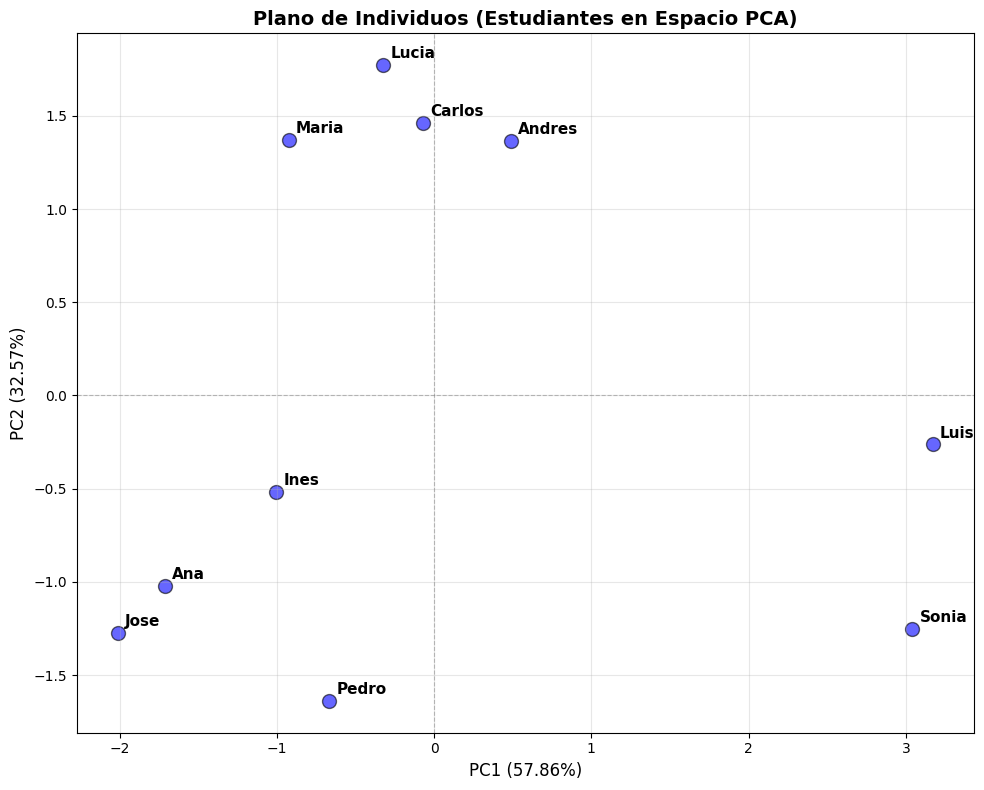

In [12]:
# Gráfica del plano de individuos
plt.figure(figsize=(10, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', s=100, alpha=0.6, edgecolors='black')

for i, nombre in enumerate(estudiantes):
    plt.annotate(nombre, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=11, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Plano de Individuos (Estudiantes en Espacio PCA)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Paso 5: Gráfica el círculo de correlación.

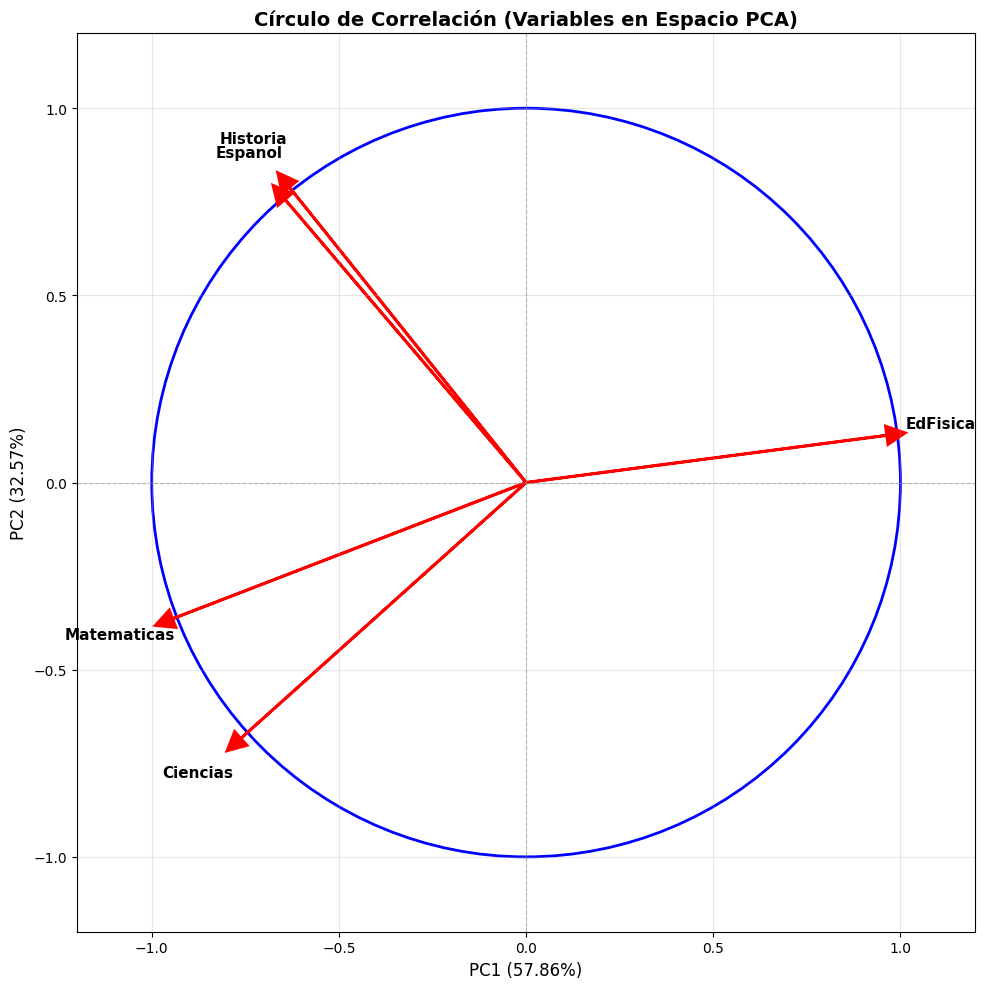

In [13]:
# Círculo de correlación
fig, ax = plt.subplots(figsize=(10, 10))

# Círculo unitario
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

# Loadings
loadings_array = pca.components_.T * np.sqrt(pca.explained_variance_)

# Vectores de variables
for i, feature in enumerate(y):
    ax.arrow(0, 0, loadings_array[i, 0], loadings_array[i, 1],
            head_width=0.05, head_length=0.05, fc='red', ec='red', linewidth=2)
    ax.text(loadings_array[i, 0] * 1.15, loadings_array[i, 1] * 1.15, 
           feature, fontsize=11, fontweight='bold', ha='center')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.set_title('Círculo de Correlación (Variables en Espacio PCA)', fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Paso 6: Interpretación de los Clusters. 

### Cluster1(Luis y Sonia) , se ve fuertemente impactado de manera positiva por las notas de educación física, es decir son buenos deportistas.

### Cluster2(Ana, Inés, José y pedro) parece ser lo opuesto al cluster 1. Sus integrantes se destacan en ciencias y matemáticas, sin embargo son malos en deportes.

### Cluster3(Andrés, Carlos, Lucía y María). se caracteriza por agrupar a los estudiantes destacados en el área de español e historia. se puede inferir también que si bien no son excelentes en deportes, al menos no son los peores, pues se encuentran en la mitad del eje x.

# Conclusiones.

### PCA significa Análisis de componentes principales (Principal Component Analysis, en inglés). Es una técnica estadística muy utilizada en ciencia de datos, aprendizaje automático y análisis de datos para reducir la dimensionalidad de un conjunto de datos, manteniendo la mayor cantidad posible de información.

# Referencias. 

### [1] John Chambers. (2008). Software for Data Analysis programming with R. USA: Springer Verlag 2008.

### [2] Jolliffe, I. T. (2002). Principal component analysis for special types of data (pp. 338-372). Springer New york.